In [31]:
import math

import matplotlib.pyplot as plt

from rgfn.gfns.reaction_gfn.api.data_structures import Molecule
import json
import random

import pandas as pd
from pathlib import Path

def clear_reaction(reaction):
    return reaction.replace(' ', '')

base_dir = Path('../data/rgfn_old')
# read txt file
# fragments_path = base_dir / 'fragments_64k.txt'
# fragments = []
# with open(fragments_path, 'r') as f:
#     for line in f:
#         fragments.append(line.strip())
# len(fragments)

reactions = pd.read_excel(base_dir / 'chemistry.xlsx', sheet_name='Reactions_NoDocking')['Reaction']
fragments = pd.read_excel(base_dir / 'chemistry.xlsx', sheet_name='Fragments_NoDocking')['Fragment']
reactions = [clear_reaction(reaction) for reaction in reactions]
fragments = [Molecule(f, idx=idx).smiles for idx, f in enumerate(fragments)]
# 
# pd.DataFrame({'smiles': fragments}).to_csv(base_dir / 'fragments.csv', index=False)
# pd.DataFrame({'reaction': reactions}).to_csv(base_dir / 'templates.csv', index=False)

# write fragments to txt file
# fragments_path = base_dir / 'fragments.txt'
# with open(fragments_path, 'w') as f:
#     for fragment in fragments:
#         f.write(fragment + '\n')
# # write reactions to txt file
# reactions_path = base_dir / 'reactions.txt'
# with open(reactions_path, 'w') as f:
#     for reaction in reactions:
#         f.write(reaction + '\n')

In [11]:
# reactions_path = '../data/synflow/templates.csv'
# reactions = []
# with open(reactions_path, 'r') as f:
#     for line in f:
#         reactions.append(line.strip())
# len(reactions)
# pd.DataFrame({'reaction': reactions}).to_csv( '../data/synflow/templates.csv', index=False)

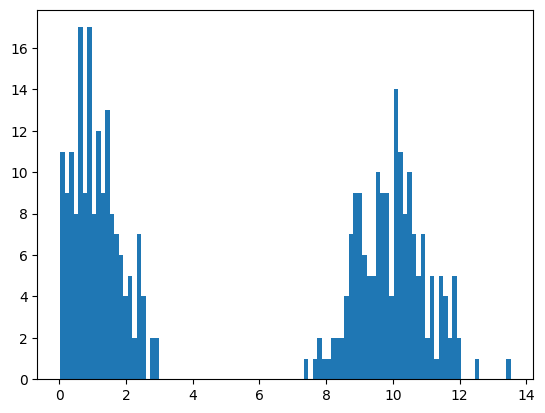

In [32]:
import scipy
def clamp(n, minn, maxn):
    return max(min(maxn, n), minn)
cost_path = base_dir / 'fragment_to_cost_2.json'
random.seed(42)
lower, upper = 0.01, 3
mu, sigma = 1, 1
small = scipy.stats.truncnorm(
    (lower - mu) / sigma, (upper - mu) / sigma, loc=mu, scale=sigma)
lower, upper = 5.0, 14.0
mu, sigma = 10, 1
large = scipy.stats.truncnorm(
    (lower - mu) / sigma, (upper - mu) / sigma, loc=mu, scale=sigma)
fragments_to_costs = {}
for fragment in fragments:
    if random.random() < 0.5:
        # fragments_to_costs[fragment] = random.uniform(0.1, 1)
        fragments_to_costs[fragment] = small.rvs()
    else:
        fragments_to_costs[fragment] = large.rvs()
#     
json.dump(fragments_to_costs, open(cost_path, 'w'), indent=2)
# set x-axis to log scale
# plt.xscale('log')
plt.hist(list(fragments_to_costs.values()), bins=100)
plt.show()

(array([22216.,  5989.,  3664.,  2499.,  1967.,  1676.,  1377.,  1225.,
         1132.,   968.,   838.,   823.,   775.,   608.,   643.,   597.,
          548.,   562.,   531.,   489.,   442.,   413.,   392.,   418.,
          381.,   367.,   377.,   343.,   294.,   312.,   322.,   309.,
          272.,   288.,   274.,   260.,   232.,   252.,   222.,   265.,
          209.,   199.,   211.,   204.,   211.,   192.,   188.,   180.,
          174.,   193.,   181.,   156.,   164.,   188.,   175.,   178.,
          159.,   164.,   171.,   157.,   161.,   145.,   163.,   121.,
          129.,   150.,   134.,   145.,   139.,   138.,   136.,   129.,
          114.,   128.,   126.,   134.,   106.,   121.,   118.,   130.,
          124.,   128.,   104.,   120.,   121.,   104.,    93.,   118.,
           99.,    92.,    99.,    97.,   109.,   122.,   100.,    97.,
          105.,    92.,    95.,    98.]),
 array([0.01000065, 0.10989916, 0.20979766, 0.30969617, 0.40959467,
        0.50949318, 0.6093

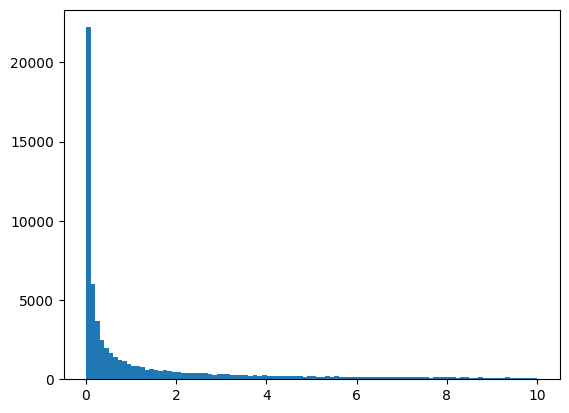